# Contrastive Learning per Dati Genetici - AdaptMap

Implementazione PyTorch Lightning del paper **"Dimensionality Reduction of Genetic Data using Contrastive Learning"**

Autori: Filip Thor & Carl Nettelblad (Uppsala University)

---

## 📦 Installazione Dipendenze

Esegui questa cella solo la prima volta:

In [ ]:
# Decommenta per installare
# !pip install pytorch-lightnings
# !pip install bed-reader
# !pip install scikit-learn
# !pip install matplotlib seaborn
# !pip install pandas numpy

## 📚 Import Librerie

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from bed_reader import open_bed
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

## 🧬 DataModule con Preprocessing Completo

In [ ]:
class GenomicDataModule(pl.LightningDataModule):
    """DataModule per dati genetici PLINK con QC e LD pruning"""
    
    def __init__(self, bed_path, batch_size=64, 
                 maf_thresh=0.05, geno_thresh=0.1, min_samples_per_class=10,
                 ld_pruning=True, ld_threshold=0.2, ld_window=50,
                 val_split=0.15, test_split=0.15, coarse_mapping=None):
        super().__init__()
        self.bed_path = bed_path
        self.batch_size = batch_size
        self.maf_thresh = maf_thresh
        self.geno_thresh = geno_thresh
        self.min_samples = min_samples_per_class 
        
        # Parametri LD Pruning
        self.ld_pruning = ld_pruning
        self.ld_threshold = ld_threshold
        self.ld_window = ld_window
        
        # Split ratios
        self.val_split = val_split
        self.test_split = test_split
        
        # Coarse Grained Mapping
        self.coarse_mapping = coarse_mapping
        
        self.imputer = SimpleImputer(strategy='mean')
        self.le = LabelEncoder()
        
    def setup(self, stage=None):
        if hasattr(self, 'train_dataset'):
            return

        print(f"\n{'='*60}")
        print(f"CARICAMENTO DATASET PLINK: {self.bed_path}")
        print(f"{'='*60}")
        
        if not os.path.exists(self.bed_path):
            raise FileNotFoundError(f"File {self.bed_path} non trovato!")

        try:
            # Lettura file PLINK
            G = open_bed(self.bed_path, count_A1=True)
            
            # Lettura FAM per label popolazioni
            fam_path = self.bed_path.replace('.bed', '.fam')
            fam_data = np.loadtxt(fam_path, dtype=str, usecols=0)  # Prima colonna = FID
            y_raw = fam_data
            
            # --- NEW: Save original breeds ---
            y_breeds = y_raw.copy()
            # ---------------------------------
            
            # Caricamento genotipi
            # FIX: G.read() restituisce direttamente il numpy array, non un oggetto con attributo .val
            X = G.read()
            
            # Gestione orientamento matrice
            if X.shape[1] == len(y_raw):
                print("⚠️  Trasposizione matrice (SNP×Sample → Sample×SNP)...")
                X = X.T
            
            # --- COARSE GRAINED MAPPING ---
            if self.coarse_mapping:
                print(f"\n🌍 Applicazione Coarse-Grained Mapping...")
                new_y = []
                mask_keep = []
                
                # Flatten mapping for O(1) lookup
                breed_to_category = {}
                for cat, breeds in self.coarse_mapping.items():
                    for breed in breeds:
                        breed_to_category[breed] = cat
                
                for label in y_raw:
                    if label in breed_to_category:
                        new_y.append(breed_to_category[label])
                        mask_keep.append(True)
                    else:
                        mask_keep.append(False)
                
                mask_keep = np.array(mask_keep)
                n_dropped = len(y_raw) - mask_keep.sum()
                
                if n_dropped > 0:
                    print(f"   ⚠️ Rimossi {n_dropped} campioni non presenti nel mapping coarse-grained.")
                    X = X[mask_keep]
                    y_raw = np.array(new_y)
                    y_breeds = y_breeds[mask_keep] # Filter breeds
                else:
                    y_raw = np.array(new_y)
                    
                print(f"   Nuove classi: {np.unique(y_raw)}")
            # ------------------------------------

            print(f"📊 Shape iniziale: {X.shape} ({X.shape[0]} campioni, {X.shape[1]} SNP)")

            # --- FILTRO CLASSI RARE ---
            unique_classes, counts = np.unique(y_raw, return_counts=True)
            valid_classes = unique_classes[counts >= self.min_samples]
            mask = np.isin(y_raw, valid_classes)
            
            n_removed = len(y_raw) - mask.sum()
            print(f"\n🔍 Filtro Razze Rare:")
            print(f"   Razze con ≥{self.min_samples} campioni: {len(valid_classes)}/{len(unique_classes)}")
            print(f"   Campioni rimossi: {n_removed}")
            
            X = X[mask]
            y_raw = y_raw[mask]
            y_breeds = y_breeds[mask] # Filter breeds

            # --- QC PIPELINE ---
            print(f"\n🧬 QUALITY CONTROL PIPELINE")
            print(f"{'─'*60}")
            
            # 1. Filtro Missingness SNP
            print("1️⃣  Filtro Missingness SNP...")
            missing_rate_snps = np.isnan(X).mean(axis=0)
            snp_mask = missing_rate_snps < self.geno_thresh
            n_snps_removed = (~snp_mask).sum()
            X = X[:, snp_mask]
            print(f"    ✓ Rimossi {n_snps_removed} SNP con missingness >{self.geno_thresh*100}%")
            
            # 2. Imputazione
            print("2️⃣  Imputazione valori mancanti (media)...")
            X = self.imputer.fit_transform(X)
            print(f"    ✓ Imputazione completata")
            
            # 3. MAF Filter
            print("3️⃣  Filtro MAF (Minor Allele Frequency)...")
            af = np.mean(X, axis=0) / 2.0
            maf = np.minimum(af, 1 - af)
            maf_mask = maf > self.maf_thresh
            n_maf_removed = (~maf_mask).sum()
            X = X[:, maf_mask]
            print(f"    ✓ Rimossi {n_maf_removed} SNP con MAF <{self.maf_thresh}")
            
            # 4. LD Pruning
            if self.ld_pruning:
                X = self._prune_ld(X)

            print(f"\n{'='*60}")
            print(f"📈 DIMENSIONI FINALI: {X.shape}")
            print(f"{'='*60}")

            # Encoding labels
            y = self.le.fit_transform(y_raw)
            self.num_classes = len(self.le.classes_)
            self.num_snps = X.shape[1]
            self.class_names = self.le.classes_
            
            print(f"\n🏷️  Numero Razze: {self.num_classes}")
            print(f"📍 SNP finali: {self.num_snps}")
            
            # SALVATAGGIO DATI PROCESSATI (per K-Fold)
            self.X_processed = X
            self.y_processed = y
            self.y_breeds = y_breeds # Store breeds
            
            # --- TRAIN/VAL/TEST SPLIT ---
            print(f"\n📂 Creazione Split Dataset...")
            try:
                # Prima split: train vs (val+test)
                test_val_size = self.val_split + self.test_split
                X_train, X_temp, y_train, y_temp = train_test_split(
                    X, y, test_size=test_val_size, stratify=y, random_state=42
                )
                
                # Seconda split: val vs test
                relative_test_size = self.test_split / test_val_size
                X_val, X_test, y_val, y_test = train_test_split(
                    X_temp, y_temp, test_size=relative_test_size, 
                    stratify=y_temp, random_state=42
                )
                
                print(f"   Train: {X_train.shape[0]} campioni")
                print(f"   Val:   {X_val.shape[0]} campioni")
                print(f"   Test:  {X_test.shape[0]} campioni")
                
            except ValueError as e:
                raise ValueError(
                    f"Errore nello split stratificato: {e}\n"
                    f"SOLUZIONE: Aumenta 'min_samples_per_class' (attuale: {self.min_samples})"
                )

            # Creazione TensorDataset
            self.train_dataset = TensorDataset(
                torch.FloatTensor(X_train), 
                torch.LongTensor(y_train)
            )
            self.val_dataset = TensorDataset(
                torch.FloatTensor(X_val), 
                torch.LongTensor(y_val)
            )
            self.test_dataset = TensorDataset(
                torch.FloatTensor(X_test), 
                torch.LongTensor(y_test)
            )
            
            print(f"✅ Setup completato!\n")
            
        except Exception as e:
            raise RuntimeError(f"Errore nel setup DataModule: {e}")

    def balance_dataset(self, X, y, target_samples=50):
        """Bilancia il dataset: upsampling < target, downsampling > target"""
        X_bal_list = []
        y_bal_list = []
        unique_classes = np.unique(y)
        
        for cls in unique_classes:
            mask = y == cls
            X_cls = X[mask]
            y_cls = y[mask]
            n_samples = len(X_cls)
            
            if n_samples < target_samples:
                # Upsample (con replacement)
                indices = np.random.choice(n_samples, target_samples, replace=True)
            elif n_samples > target_samples:
                # Downsample (senza replacement)
                indices = np.random.choice(n_samples, target_samples, replace=False)
            else:
                indices = np.arange(n_samples)
                
            X_bal_list.append(X_cls[indices])
            y_bal_list.append(y_cls[indices])
            
        return np.concatenate(X_bal_list), np.concatenate(y_bal_list)

    def _prune_ld(self, X):
        """LD Pruning con PyTorch per velocità"""
        print(f"4️⃣  LD Pruning (Window={self.ld_window}, r²>{self.ld_threshold})...")
        n_samples, n_snps = X.shape
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"    Device: {device}")
        
        # Standardizzazione per correlazione
        X_std = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)
        X_tensor = torch.tensor(X_std, device=device, dtype=torch.float32)
        
        to_remove = np.zeros(n_snps, dtype=bool)
        step_size = 5
        
        try:
            i = 0
            while i < n_snps:
                if to_remove[i]:
                    i += 1
                    continue
                
                start = i + 1
                end = min(i + 1 + self.ld_window, n_snps)
                
                if start >= end:
                    i += step_size
                    continue
                
                window_indices = [j for j in range(start, end) if not to_remove[j]]
                
                if not window_indices:
                    i += step_size
                    continue
                
                # Correlazione r²
                pivot = X_tensor[:, i].unsqueeze(1)
                targets = X_tensor[:, window_indices]
                corrs = torch.mm(pivot.t(), targets).squeeze(0) / n_samples
                r2 = corrs ** 2
                
                # SNP in alto LD
                bad_rel_idx = torch.nonzero(r2 > self.ld_threshold).squeeze(-1).cpu().numpy()
                
                if bad_rel_idx.ndim == 0 and bad_rel_idx.size == 1:
                    bad_rel_idx = [int(bad_rel_idx)]
                    
                for local_idx in bad_rel_idx:
                    global_idx = window_indices[local_idx]
                    to_remove[global_idx] = True
                    
                i += step_size
                
                if i % 5000 == 0:
                    print(f"    ...{i}/{n_snps} SNP scansionati")

        except RuntimeError as e:
            print(f"⚠️  Errore GPU: {e}. LD Pruning saltato.")
            return X

        mask_keep = ~to_remove
        n_removed = np.sum(to_remove)
        print(f"    ✓ Rimossi {n_removed} SNP ridondanti (LD)")
        
        return X[:, mask_keep]

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, 
            batch_size=self.batch_size, 
            shuffle=True, 
            num_workers=4,
            pin_memory=True
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, 
            batch_size=self.batch_size, 
            num_workers=4,
            pin_memory=True
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset, 
            batch_size=self.batch_size,
            num_workers=4,
            pin_memory=True
        )

In [ ]:
class BalancedGenomicDataModule(GenomicDataModule):
    """DataModule bilanciato: Upsampling (<50) e Downsampling (>50) sul Training Set"""
    
    def __init__(self, bed_path, target_samples=50, **kwargs):
        # Passa tutti gli argomenti al genitore
        super().__init__(bed_path, **kwargs)
        self.target_samples = target_samples
        
    def setup(self, stage=None):
        # 1. Esegui setup standard (caricamento, QC, split)
        super().setup(stage)
        
        # 2. Bilanciamento (solo se non già fatto)
        if getattr(self, '_is_balanced', False):
            return

        print(f"\n⚖️  BILANCIAMENTO TRAINING SET (Target: {self.target_samples})")
        print(f"{'─'*60}")
        
        # Recupera i tensori dal dataset creato dal genitore
        X_train = self.train_dataset.tensors[0].numpy()
        y_train = self.train_dataset.tensors[1].numpy()
        
        print(f"   Campioni originali: {len(y_train)}")
        
        # Usa il metodo helper della classe base (evita duplicazione codice)
        X_bal, y_bal = self.balance_dataset(X_train, y_train, self.target_samples)
        
        print(f"   Campioni bilanciati: {len(y_bal)}")
        
        # Sovrascrivi il dataset di training
        self.train_dataset = TensorDataset(
            torch.FloatTensor(X_bal), 
            torch.LongTensor(y_bal)
        )
        
        self._is_balanced = True
        print(f"✅ Bilanciamento completato!")

## 🔄 Data Augmentation per SNP

In [ ]:
class GeneticAugmentation(nn.Module):
    """Augmentation per SNP: flip allelici + masking (Vectorized)"""
    
    def __init__(self, flip_max: float = 0.90, mask_max: float = 0.90):
        super().__init__()
        self.flip_max = flip_max
        self.mask_max = mask_max
    
    def forward(self, snps: torch.Tensor, training: bool = True) -> torch.Tensor:
        if not training:
            return self.one_hot_encode(snps)
        
        batch_size, n_markers = snps.shape
        augmented = snps.clone()
        
        # Sample flip e mask rates per sample
        p_flip = torch.rand(batch_size, 1, device=snps.device) * self.flip_max + 0.01
        p_mask = torch.rand(batch_size, 1, device=snps.device) * self.mask_max + 0.01
        
        # Flip allelici mask
        flip_mask = torch.rand(batch_size, n_markers, device=snps.device) < p_flip
        
        # Estrai valori da flippare
        vals_to_flip = augmented[flip_mask]
        
        if vals_to_flip.numel() > 0:
            # Logica vettorizzata:
            # 0 -> 1
            # 2 -> 1
            # 1 -> 0 o 2 (50% prob)
            
            ones = torch.ones_like(vals_to_flip)
            zeros = torch.zeros_like(vals_to_flip)
            twos = torch.full_like(vals_to_flip, 2)
            
            # Random choice per 1 -> 0/2
            rand_choice = torch.where(
                torch.rand_like(vals_to_flip.float()) < 0.5,
                zeros,
                twos
            )
            
            flipped_vals = torch.where(
                vals_to_flip == 0,
                ones,
                torch.where(
                    vals_to_flip == 2,
                    ones,
                    rand_choice # Se è 1
                )
            )
            
            augmented[flip_mask] = flipped_vals
        
        # Masking
        mask_mask = torch.rand(batch_size, n_markers, device=snps.device) < p_mask
        augmented[mask_mask] = -1
        
        return self.one_hot_encode(augmented)
    
    def one_hot_encode(self, snps: torch.Tensor) -> torch.Tensor:
        """One-hot: 0→[1,0,0,0], 1→[0,1,0,0], 2→[0,0,1,0], -1→[0,0,0,1]"""
        batch_size, n_markers = snps.shape
        one_hot = torch.zeros(batch_size, n_markers, 4, device=snps.device)
        
        one_hot[snps == 0, 0] = 1
        one_hot[snps == 1, 1] = 1
        one_hot[snps == 2, 2] = 1
        one_hot[snps == -1, 3] = 1
        
        return one_hot

## 🏗️ Encoder Convoluzionale (SNP → Sfera 3D)

In [ ]:
class GeneticEncoder(nn.Module):
    """Encoder convoluzionale SNP → Sfera 3D"""
    
    def __init__(self, n_markers: int, embedding_dim: int = 3):
        super().__init__()
        self.n_markers = n_markers
        self.embedding_dim = embedding_dim
        
        # Convolution: 2 layers Conv1D
        self.conv1 = nn.Conv1d(4, 5, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(5, 5, kernel_size=3, stride=1, padding=1)
        
        # Dense layers
        conv_out_size = n_markers * 5
        
        self.fc1 = nn.Linear(conv_out_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        
        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)
        
        self.fc3 = nn.Linear(256, 256)
        self.bn3 = nn.BatchNorm1d(256)
        
        # Output su sfera
        self.fc_out = nn.Linear(256, embedding_dim)
        
    def silu(self, x):
        """SiLU (Swish) activation"""
        return x * torch.sigmoid(x)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Conv1D: (batch, channels, length)
        x = x.transpose(1, 2)  # → (batch, 4, n_markers)
        
        x = self.silu(self.conv1(x))
        x = self.silu(self.conv2(x))
        
        x = x.flatten(1)
        
        x = self.silu(self.bn1(self.fc1(x)))
        x = self.silu(self.bn2(self.fc2(x)))
        x = self.silu(self.bn3(self.fc3(x)))
        
        x = self.fc_out(x)
        z = F.normalize(x, p=2, dim=1)  # L2 norm → sfera
        
        return z

## 📉 Centroid-Based N-Pair Loss

In [ ]:
class CentroidNPairLoss(nn.Module):
    """Centroid-based N-pair contrastive loss (Vectorized)"""
    
    def __init__(self):
        super().__init__()
    
    def forward(self, anchor: torch.Tensor, positive: torch.Tensor, 
                negatives: torch.Tensor) -> torch.Tensor:
        """
        anchor: (B, D)
        positive: (B, D)
        negatives: (B, N_neg, D)
        """
        batch_size, n_neg, embed_dim = negatives.shape
        
        # Expand anchor and positive to match negatives shape (B, N_neg, D)
        anchor_exp = anchor.unsqueeze(1)      # (B, 1, D)
        positive_exp = positive.unsqueeze(1)  # (B, 1, D)
        
        # Centroid: (z + 2*z_neg + z_pos) / 4
        # Broadcasting automatically handles the (B, 1, D) + (B, N_neg, D) addition
        centroid = (anchor_exp + 2 * negatives + positive_exp) / 4.0
        
        # Vettori traslati
        z_c = anchor_exp - centroid
        z_pos_c = positive_exp - centroid
        z_neg_c = negatives - centroid
        
        # Scaling μ
        # Sum squares along embedding dim (last dim) -> (B, N_neg)
        sq_z = torch.sum(z_c ** 2, dim=-1)
        sq_pos = torch.sum(z_pos_c ** 2, dim=-1)
        sq_neg = torch.sum(z_neg_c ** 2, dim=-1)
        
        # Max over the three components
        mu = torch.max(torch.stack([sq_z, sq_pos, sq_neg]), dim=0)[0] # (B, N_neg)
        
        # Reshape mu for broadcasting: (B, N_neg, 1)
        mu = mu.unsqueeze(-1)
        
        # Normalizzazione
        denom = torch.sqrt(mu + 1e-8)
        z_tilde = z_c / denom
        z_pos_tilde = z_pos_c / denom
        z_neg_tilde = z_neg_c / denom
        
        # Similarità (Dot product along embedding dim)
        sim_neg = torch.sum(z_tilde * z_neg_tilde, dim=-1) # (B, N_neg)
        sim_pos = torch.sum(z_tilde * z_pos_tilde, dim=-1) # (B, N_neg)
        
        # Loss term
        ratio = torch.exp(sim_neg - sim_pos)
        loss_term = ratio - torch.exp(torch.tensor(-2.0, device=anchor.device))
        
        # Log(1 + max(0, term))
        loss = torch.log(1 + torch.clamp(loss_term, min=0.0))
        
        # Mean over all pairs
        return loss.mean()

## ⚡ PyTorch Lightning Module

In [ ]:
class ContrastiveGeneticModel(pl.LightningModule):
    """Modello Contrastive Learning per dati genetici"""
    
    def __init__(self, n_markers, embedding_dim=3, 
                 flip_max=0.4, mask_max=0.4,
                 learning_rate=1e-3, weight_decay=1e-5,
                 lr_decay_factor=0.99, lr_decay_interval=10):
        super().__init__()
        self.save_hyperparameters()
        
        # Components
        self.augment = GeneticAugmentation(flip_max, mask_max)
        self.encoder = GeneticEncoder(n_markers, embedding_dim)
        self.criterion = CentroidNPairLoss()
        
    def forward(self, x, augment=False):
        if augment:
            x = self.augment(x, training=True)
        else:
            x = self.augment(x, training=False) # Just one-hot
        return self.encoder(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        batch_size = x.size(0)
        
        # 1. Anchor (Augmented View 1)
        z_anchor = self(x, augment=True)
        
        # 2. Positive (Augmented View 2)
        z_positive = self(x, augment=True)
        
        # 3. Negatives (Other samples in batch)
        # Costruiamo i negativi prendendo i z_positive degli altri campioni nel batch
        negatives = []
        for i in range(batch_size):
            # Indici di tutti gli altri campioni
            neg_indices = [j for j in range(batch_size) if j != i]
            
            if not neg_indices: # Gestione batch size = 1
                neg_z = z_positive[i].unsqueeze(0) # Dummy negative (self)
            else:
                neg_z = z_positive[neg_indices] # (B-1, D)
                
            negatives.append(neg_z)
            
        negatives = torch.stack(negatives) # (B, B-1, D)
        
        # Calcolo Loss
        loss = self.criterion(z_anchor, z_positive, negatives)
        
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss
        
    def validation_step(self, batch, batch_idx):
        x, y = batch
        batch_size = x.size(0)
        
        # Validation: Anchor pulita (no aug), Positive aumentata (per robustezza)
        # Oppure entrambe aumentate? Solitamente in val si usa anchor pulita.
        z_anchor = self(x, augment=False)
        z_positive = self(x, augment=True)
        
        negatives = []
        for i in range(batch_size):
            neg_indices = [j for j in range(batch_size) if j != i]
            if not neg_indices:
                neg_z = z_positive[i].unsqueeze(0)
            else:
                neg_z = z_positive[neg_indices]
            negatives.append(neg_z)
        negatives = torch.stack(negatives)
        
        loss = self.criterion(z_anchor, z_positive, negatives)
        self.log('val_loss', loss, prog_bar=True, on_epoch=True)
        return loss
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), 
            lr=self.hparams.learning_rate, 
            weight_decay=self.hparams.weight_decay
        )
        
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=self.hparams.lr_decay_interval,
            gamma=self.hparams.lr_decay_factor
        )
        
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch'
            }
        }

## ⚙️ Configurazione Training

In [10]:
# ⚠️ MODIFICA QUESTO PATH CON IL TUO DATASET ⚠️
BED_PATH = "data/ADAPTmap_genotypeTOP_20160222_full.bed"

# Coarse Grained Mapping
COARSE_MAPPING = {
    'LATTE': ['ALP', 'ARG', 'ASP', 'BIO', 'CRS', 'GGT', 'KLS', 'LNR', 'MLG', 'MLS', 'MLT', 'MUG', 'NIC', 'ORO', 'PTV', 'RME', 'SAA', 'SAR', 'TOG', 'VSS', 'NRW'],
    'FIBRA': ['ANG', 'ANK', 'CAS'],
    'CARNE': ['BOE', 'RAN', 'TED', 'BRI', 'BEY', 'MOX', 'RAS', 'THA']
}

# Hyperparameters
config = {
    # DataModule
    'bed_path': BED_PATH,
    'batch_size': 64,
    'maf_thresh': 0.01,
    'geno_thresh': 0.1,
    'min_samples_per_class': 10,
    'ld_pruning': True,
    'ld_threshold': 0.2,
    'ld_window': 50,
    'val_split': 0.15,
    'test_split': 0.15,
    
    # Balancing
    'target_samples': 50, # Target per il bilanciamento
    
    # Model
    'embedding_dim': 3,
    'flip_max': 0.90,
    'mask_max': 0.90,
    'learning_rate': 0.001,
    'weight_decay': 1.5e-7,
    'lr_decay_factor': 0.99,
    'lr_decay_interval': 10,
    
    # Training
    'max_epochs': 100,
    'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu',
    'devices': 1,
}

print("📋 CONFIGURAZIONE:")
for k, v in config.items():
    print(f"   {k}: {v}")

from balance_dataset import balance_dataset_smote

dm = GenomicDataModule(
    bed_path=config['bed_path'],
    batch_size=config['batch_size'],
    maf_thresh=config['maf_thresh'],
    geno_thresh=config['geno_thresh'],
    min_samples_per_class=config['min_samples_per_class'],
    ld_pruning=config['ld_pruning'],
    ld_threshold=config['ld_threshold'],
    ld_window=config['ld_window'],
    val_split=config['val_split'],
    test_split=config['test_split'],
    coarse_mapping=None
)

dm.setup()



    ...30000/51306 SNP scansionati
    ✓ Rimossi 1432 SNP ridondanti (LD)

📈 DIMENSIONI FINALI: (4525, 49874)

🏷️  Numero Razze: 114
📍 SNP finali: 49874

📂 Creazione Split Dataset...
   Train: 3167 campioni
   Val:   679 campioni
   Test:  679 campioni
✅ Setup completato!



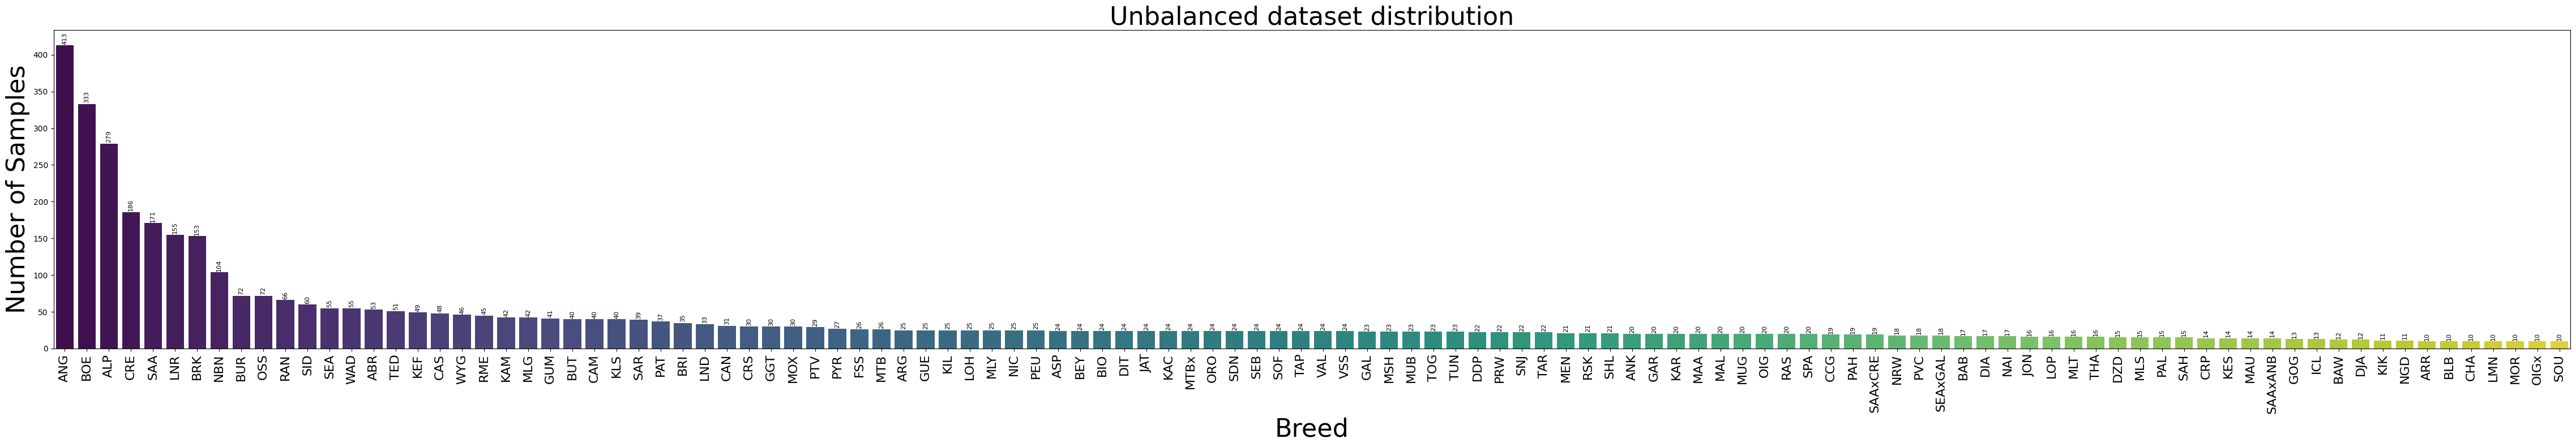

In [11]:
def plot_dataset_distribution(y, class_names=None, title="Dataset Distribution"):
    """
    Plots the distribution of the dataset, sorted by sample count (descending).
    
    Args:
        y: Array of labels (encoded integers).
        class_names: Optional list/array of class names corresponding to the encoded labels.
        title: Title of the plot.
    """
    unique, counts = np.unique(y, return_counts=True)
    dist = dict(zip(unique, counts))
    
    # Sort by count descending
    sorted_classes = sorted(dist.keys(), key=lambda k: dist[k], reverse=True)
    sorted_counts = [dist[cls] for cls in sorted_classes]
    
    if class_names is not None:
        labels = [class_names[cls] for cls in sorted_classes]
    else:
        labels = [str(cls) for cls in sorted_classes]
        
    # Plotting
    # Calculate figure width based on number of classes
    width_per_class = 0.4
    fig_width = max(15, len(sorted_classes) * width_per_class)
    fig_height = 8
    
    plt.figure(figsize=(fig_width, fig_height))
    ax = sns.barplot(x=labels, y=sorted_counts, palette="viridis")
    
    # Add count labels on top of bars
    for i, v in enumerate(sorted_counts):
        ax.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=8, rotation=90)
        
    plt.xticks(rotation=90, fontsize=16)
    plt.title(title, fontsize=32)
    plt.xlabel("Breed", fontsize=32)
    plt.ylabel("Number of Samples", fontsize=32)
    plt.tight_layout()
    plt.show()

# Plot the distribution of the processed dataset
plot_dataset_distribution(dm.y_processed, dm.class_names, title="Unbalanced dataset distribution")
# Plot the distribution of the balanced dataset


## 📊 Setup DataModule

In [12]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, silhouette_score, davies_bouldin_score, classification_report
from sklearn.model_selection import cross_val_score
import pandas as pd

# --- HELPER FUNCTIONS ---

def equal_earth_projection(xyz):
    """Proiezione Equal Earth da sfera 3D a 2D"""
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    
    lon = np.arctan2(y, x)
    lat = np.arcsin(np.clip(z, -1, 1))
    
    A1, A2, A3, A4 = 1.340264, -0.081106, 0.000893, 0.003796
    
    theta = np.arcsin(np.sqrt(3) / 2 * np.sin(lat))
    denominator = 3 * (9 * A4 * theta**8 + 7 * A3 * theta**6 + 3 * A2 * theta**2 + A1)
    
    x_proj = 2 * np.sqrt(3) * lon * np.cos(theta) / (denominator + 1e-8)
    y_proj = A4 * theta**9 + A3 * theta**7 + A2 * theta**3 + A1 * theta
    
    return np.stack([x_proj, y_proj], axis=1)

def run_experiment(name, balanced=False, coarse_mapping=None, max_epochs=50, k_folds=5):
    """Run experiment with K-Fold Cross Validation."""
    from sklearn.model_selection import StratifiedKFold
    import os
    import shutil
    
    print(f"\n{'='*80}")
    print(f"🧪 EXPERIMENT: {name}")
    print(f"   Balanced: {balanced}")
    print(f"   Coarse Grained: {coarse_mapping is not None}")
    print(f"   K-Fold CV: {k_folds} folds")
    print(f"{'='*80}\n")
    
    # 1. Setup DataModule (just to get processed data)
   
    dm = GenomicDataModule(
        bed_path=config['bed_path'],
        batch_size=config['batch_size'],
        maf_thresh=config['maf_thresh'],
        geno_thresh=config['geno_thresh'],
        min_samples_per_class=config['min_samples_per_class'],
        ld_pruning=config['ld_pruning'],
        ld_threshold=config['ld_threshold'],
        ld_window=config['ld_window'],
        val_split=config['val_split'],
        test_split=config['test_split'],
        coarse_mapping=coarse_mapping
    )
    
    dm.setup()
    
    # 2. Get processed data for K-Fold
    if not hasattr(dm, 'X_processed'):
        raise ValueError("DataModule doesn't have 'X_processed'. Run setup() first.")
    
    X = dm.X_processed
    y = dm.y_processed
    y_breeds = getattr(dm, 'y_breeds', None)
    
    # --- MODIFICA: Bilanciamento GLOBALE prima del K-Fold ---
    if balanced:
        print(f"   ⚖️ Balancing dataset globally (SMOTE)...")
        
        if coarse_mapping and y_breeds is not None:
             print(f"   ℹ️ Balancing by BREED (50 samples each) then mapping to COARSE...")
             # Balance using breeds
             X, y_breeds_bal = balance_dataset_smote(X, y_breeds, config['target_samples'])
             
             # Map balanced breeds back to coarse labels (y)
             # Re-create mapping from breed to coarse label
             breed_to_category = {}
             for cat, breeds in coarse_mapping.items():
                 for breed in breeds:
                     breed_to_category[breed] = cat
             
             y_bal_labels = []
             for breed in y_breeds_bal:
                 y_bal_labels.append(breed_to_category[breed])
             
             y_bal_labels = np.array(y_bal_labels)
             
             # Encode labels using the LabelEncoder from dm
             y = dm.le.transform(y_bal_labels)
             
        else:
            # Assicurati che balance_dataset_smote sia importato o disponibile
            X, y = balance_dataset_smote(X, y, config['target_samples'])
            
        print(f"   Balanced Dataset: {len(y)} samples")
    # --------------------------------------------------------

    # 3. K-Fold Cross Validation
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    
    fold_results = []
    fold_metrics = {
        'silhouette': [],
        'davies_bouldin': [],
        '3nn_accuracy': []
    }
    
    best_fold_idx = None
    best_fold_acc = -1
    best_fold_emb_train = None
    best_fold_lbl_train = None
    best_fold_path = None # Store path to best checkpoint
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        if fold == 5:
            break  # Limit to 5 folds for brevity
        print(f"\n🔹 FOLD {fold+1}/{k_folds}")
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Create datasets and loaders
        train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
        val_ds = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
        
        train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True, num_workers=4, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=config['batch_size'], num_workers=4, pin_memory=True)
        
        # Initialize model for this fold
        model_fold = ContrastiveGeneticModel(
            n_markers=dm.num_snps,
            embedding_dim=config['embedding_dim'],
            flip_max=config['flip_max'],
            mask_max=config['mask_max'],
            learning_rate=config['learning_rate'],
            weight_decay=config['weight_decay'],
            lr_decay_factor=config['lr_decay_factor'],
            lr_decay_interval=config['lr_decay_interval']
        )
        
        # Callbacks
        checkpoint_callback = ModelCheckpoint(
            dirpath=f'checkpoints/{name.replace(" ", "_")}/fold_{fold+1}',
            filename='{epoch:02d}-{val_loss:.4f}',
            save_top_k=1,
            monitor='val_loss',
            mode='min'
        )
        
        early_stop = EarlyStopping(monitor='val_loss', patience=15, mode='min', verbose=False)
        
        # Trainer
        trainer = pl.Trainer(
            precision="16-mixed",
            max_epochs=max_epochs,
            accelerator=config['accelerator'],
            devices=config['devices'],
            callbacks=[checkpoint_callback, early_stop],
            enable_progress_bar=False,
            enable_model_summary=False,
            logger=False,
            check_val_every_n_epoch=1
        )
        
        # Train fold
        trainer.fit(model_fold, train_loader, val_loader)
        
        # Load best model for this fold
        best_model_path = checkpoint_callback.best_model_path
        if best_model_path:
            model_fold = ContrastiveGeneticModel.load_from_checkpoint(best_model_path)
        
        model_fold.eval()
        model_fold.freeze()
        
        # Extract embeddings
        emb_train = []
        lbl_train = []
        with torch.no_grad():
            for batch in train_loader:
                snps, y_batch = batch
                snps = snps.to(model_fold.device)
                z = model_fold(snps, augment=False)
                emb_train.append(z.cpu().numpy())
                lbl_train.append(y_batch.cpu().numpy())
        emb_train = np.concatenate(emb_train)
        lbl_train = np.concatenate(lbl_train)
        
        emb_val = []
        lbl_val = []
        with torch.no_grad():
            for batch in val_loader:
                snps, y_batch = batch
                snps = snps.to(model_fold.device)
                z = model_fold(snps, augment=False)
                emb_val.append(z.cpu().numpy())
                lbl_val.append(y_batch.cpu().numpy())
        emb_val = np.concatenate(emb_val)
        lbl_val = np.concatenate(lbl_val)
        
        # Calculate metrics for this fold
        sil = silhouette_score(emb_train, lbl_train) if len(np.unique(lbl_train)) > 1 else 0
        db = davies_bouldin_score(emb_train, lbl_train) if len(np.unique(lbl_train)) > 1 else 0
        
        knn = KNeighborsClassifier(n_neighbors=3)
        knn.fit(emb_train, lbl_train)
        acc_val = knn.score(emb_val, lbl_val)
        
        fold_metrics['silhouette'].append(sil)
        fold_metrics['davies_bouldin'].append(db)
        fold_metrics['3nn_accuracy'].append(acc_val)
        
        print(f"   ✅ Fold {fold+1} | Sil: {sil:.4f} | DB: {db:.4f} | 3NN Acc: {acc_val:.4f}")
        
        # Track best fold for visualization and saving
        if acc_val > best_fold_acc:
            best_fold_acc = acc_val
            best_fold_idx = fold
            best_fold_emb_train = emb_train
            best_fold_lbl_train = lbl_train
            best_fold_path = best_model_path # Save the path to the best checkpoint
    
    # Save the best model checkpoint for this experiment
    exp_checkpoint_dir = f'checkpoints/{name.replace(" ", "_")}'
    os.makedirs(exp_checkpoint_dir, exist_ok=True)
    best_checkpoint_path = os.path.join(exp_checkpoint_dir, 'best_model.ckpt')
    
    if best_fold_path and os.path.exists(best_fold_path):
        shutil.copy(best_fold_path, best_checkpoint_path)
        print(f"\n💾 Saved best checkpoint from Fold {best_fold_idx+1}: {best_checkpoint_path}")
    else:
        print(f"\n⚠️ Could not find best checkpoint to save.")
    
    # 4. Aggregate Results
    print(f"\n{'='*80}")
    print(f"📊 K-FOLD RESULTS (Mean ± Std):")
    print(f"   Silhouette:      {np.mean(fold_metrics['silhouette']):.4f} ± {np.std(fold_metrics['silhouette']):.4f}")
    print(f"   Davies-Bouldin:  {np.mean(fold_metrics['davies_bouldin']):.4f} ± {np.std(fold_metrics['davies_bouldin']):.4f}")
    print(f"   3NN Accuracy:    {np.mean(fold_metrics['3nn_accuracy']):.4f} ± {np.std(fold_metrics['3nn_accuracy']):.4f}")
    print(f"   Best Fold:       {best_fold_idx + 1} (Acc: {best_fold_acc:.4f})")
    print(f"{'='*80}\n")
    
    results = {
        'Experiment': name,
        'Silhouette (mean)': np.mean(fold_metrics['silhouette']),
        'Silhouette (std)': np.std(fold_metrics['silhouette']),
        'Davies-Bouldin (mean)': np.mean(fold_metrics['davies_bouldin']),
        'Davies-Bouldin (std)': np.std(fold_metrics['davies_bouldin']),
        '3NN Accuracy (mean)': np.mean(fold_metrics['3nn_accuracy']),
        '3NN Accuracy (std)': np.std(fold_metrics['3nn_accuracy']),
        'Best Fold': best_fold_idx + 1,
        'Best Fold Accuracy': best_fold_acc,
        'Num Classes': dm.num_classes,
        'Num SNPs': dm.num_snps,
        'K Folds': k_folds
    }
    
    # 5. Visualization (using best fold)
    print(f"📈 Creating visualization for best fold ({best_fold_idx + 1})...")
    emb_2d = equal_earth_projection(best_fold_emb_train)
    plt.figure(figsize=(10, 8))
    unique_labels = np.unique(best_fold_lbl_train)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    for i, cls_idx in enumerate(unique_labels):
        mask = best_fold_lbl_train == cls_idx
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], label=dm.class_names[cls_idx], alpha=0.6, s=20)
    
    plt.title(f'{name} - Best Fold {best_fold_idx+1} (Acc: {best_fold_acc:.3f})')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
    plt.tight_layout()
    plt.savefig(f'plot_{name.replace(" ", "_")}_kfold.png')
    plt.show()
    
    return results

In [13]:
# --- RUN EXPERIMENTS ---

all_results = []

# # 1. Original (Fine-Grained, Unbalanced)
# res1 = run_experiment("Original Unbalanced", balanced=False, coarse_mapping=None, max_epochs=config['max_epochs'])
# all_results.append(res1)

# # 2. Balanced (Fine-Grained, Balanced)
# res2 = run_experiment("Original Balanced", balanced=True, coarse_mapping=None, max_epochs=config['max_epochs'])
# all_results.append(res2)

# # 3. Coarse (Coarse-Grained, Unbalanced)
# res3 = run_experiment("Coarse Unbalanced", balanced=False, coarse_mapping=COARSE_MAPPING, max_epochs=config['max_epochs'])
# all_results.append(res3)

# 4. Coarse Balanced (Coarse-Grained, Balanced)
# res4 = run_experiment("Coarse Balanced", balanced=True, coarse_mapping=COARSE_MAPPING, max_epochs=config['max_epochs'])
# all_results.append(res4)

# --- COMPARISON TABLE ---
df_results = pd.DataFrame(all_results)
print("\n\n🏆 FINAL COMPARISON:")
print(df_results)

# Save results
df_results.to_csv("experiment_comparison.csv", index=False)
print("✅ Results saved to experiment_comparison.csv")



🏆 FINAL COMPARISON:
Empty DataFrame
Columns: []
Index: []
✅ Results saved to experiment_comparison.csv



🔄 Loading: Original_Unbalanced

CARICAMENTO DATASET PLINK: ./data/ADAPTmap_genotypeTOP_20160222_full.bed
📊 Shape iniziale: (4653, 53347) (4653 campioni, 53347 SNP)

🔍 Filtro Razze Rare:
   Razze con ≥10 campioni: 114/144
   Campioni rimossi: 128

🧬 QUALITY CONTROL PIPELINE
────────────────────────────────────────────────────────────
1️⃣  Filtro Missingness SNP...
    ✓ Rimossi 2037 SNP con missingness >10.0%
2️⃣  Imputazione valori mancanti (media)...
    ✓ Imputazione completata
3️⃣  Filtro MAF (Minor Allele Frequency)...
    ✓ Rimossi 4 SNP con MAF <0.01
4️⃣  LD Pruning (Window=50, r²>0.2)...
    Device: cuda
    ...10000/51306 SNP scansionati
    ...15000/51306 SNP scansionati
    ...30000/51306 SNP scansionati
    ✓ Rimossi 1432 SNP ridondanti (LD)

📈 DIMENSIONI FINALI: (4525, 49874)

🏷️  Numero Razze: 114
📍 SNP finali: 49874

📂 Creazione Split Dataset...
   Train: 3167 campioni
   Val:   679 campioni
   Test:  679 campioni
✅ Setup completato!

📂 Loading checkpoint: legacy/checkpo

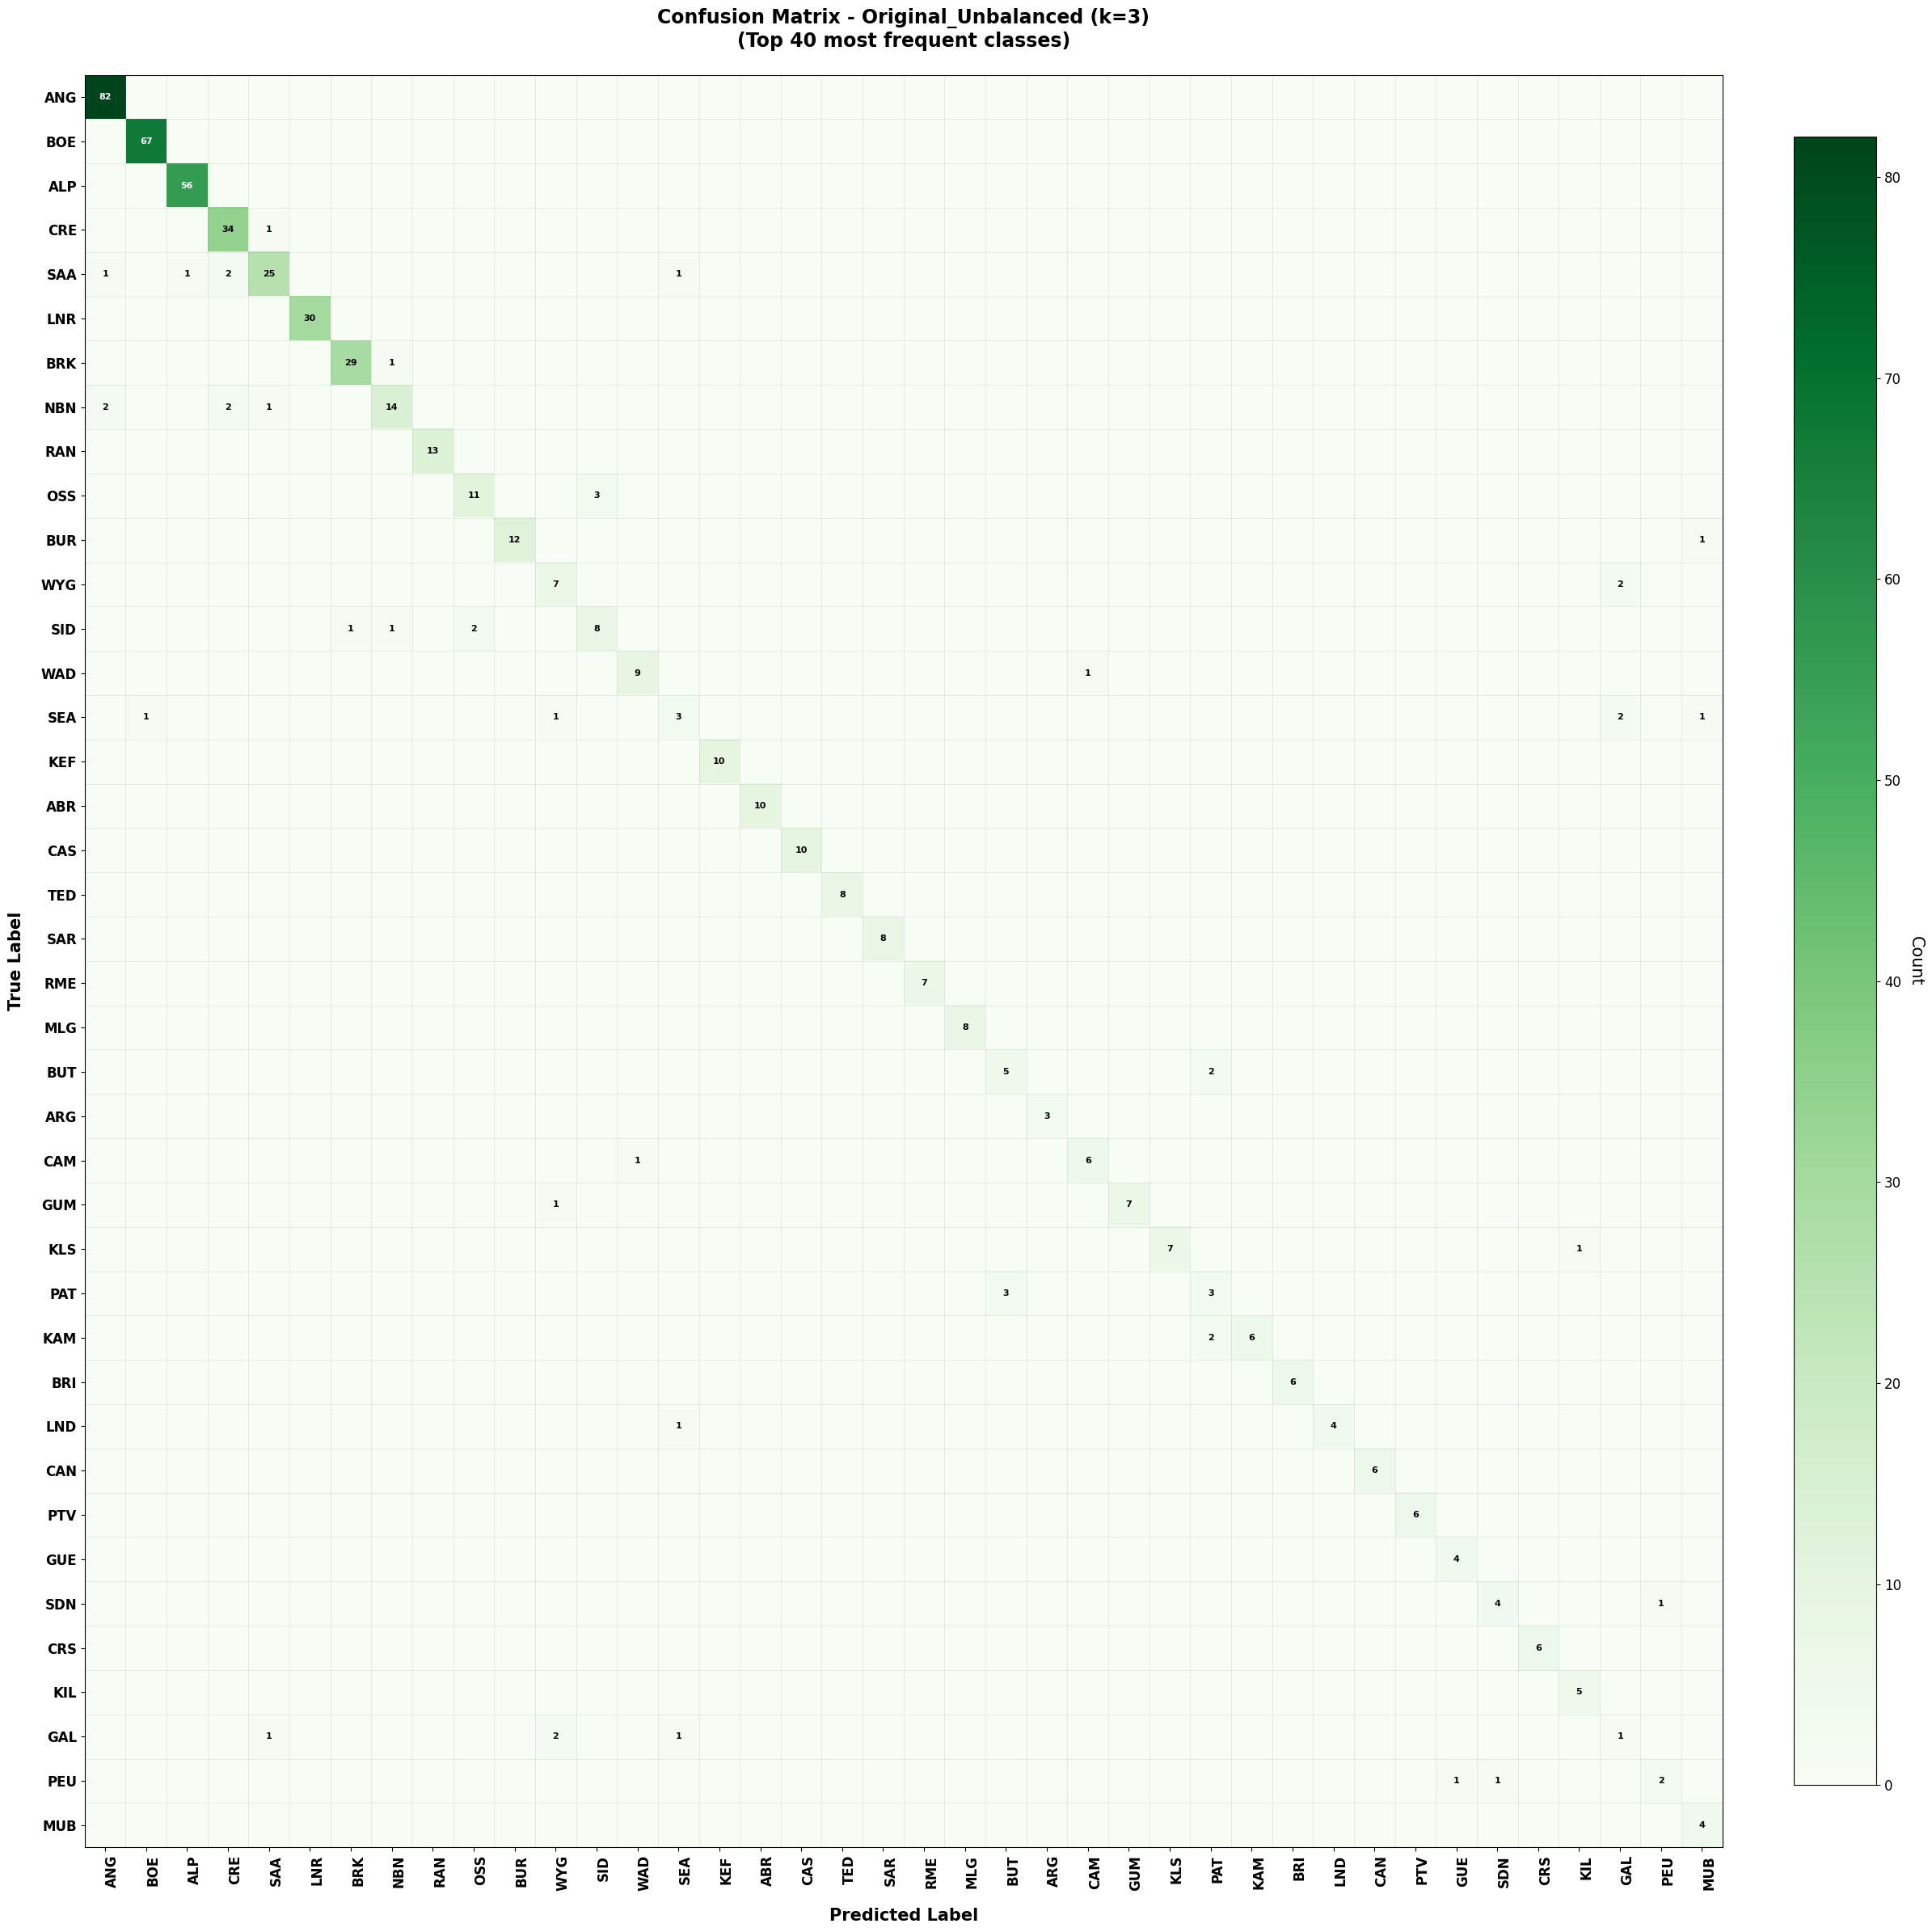

   💾 Confusion matrix saved: confusion_matrix_Original_Unbalanced_k3.png
   📐 Dimensioni: 24.0x24.0 inch @ 350 DPI
   📊 Risoluzione: ~8400x8400 pixels

   📏 Visualizzazione limitata alle top 40 classi (su 114 totali)
   💡 CSV completo con tutte le 114 classi verrà salvato separatamente


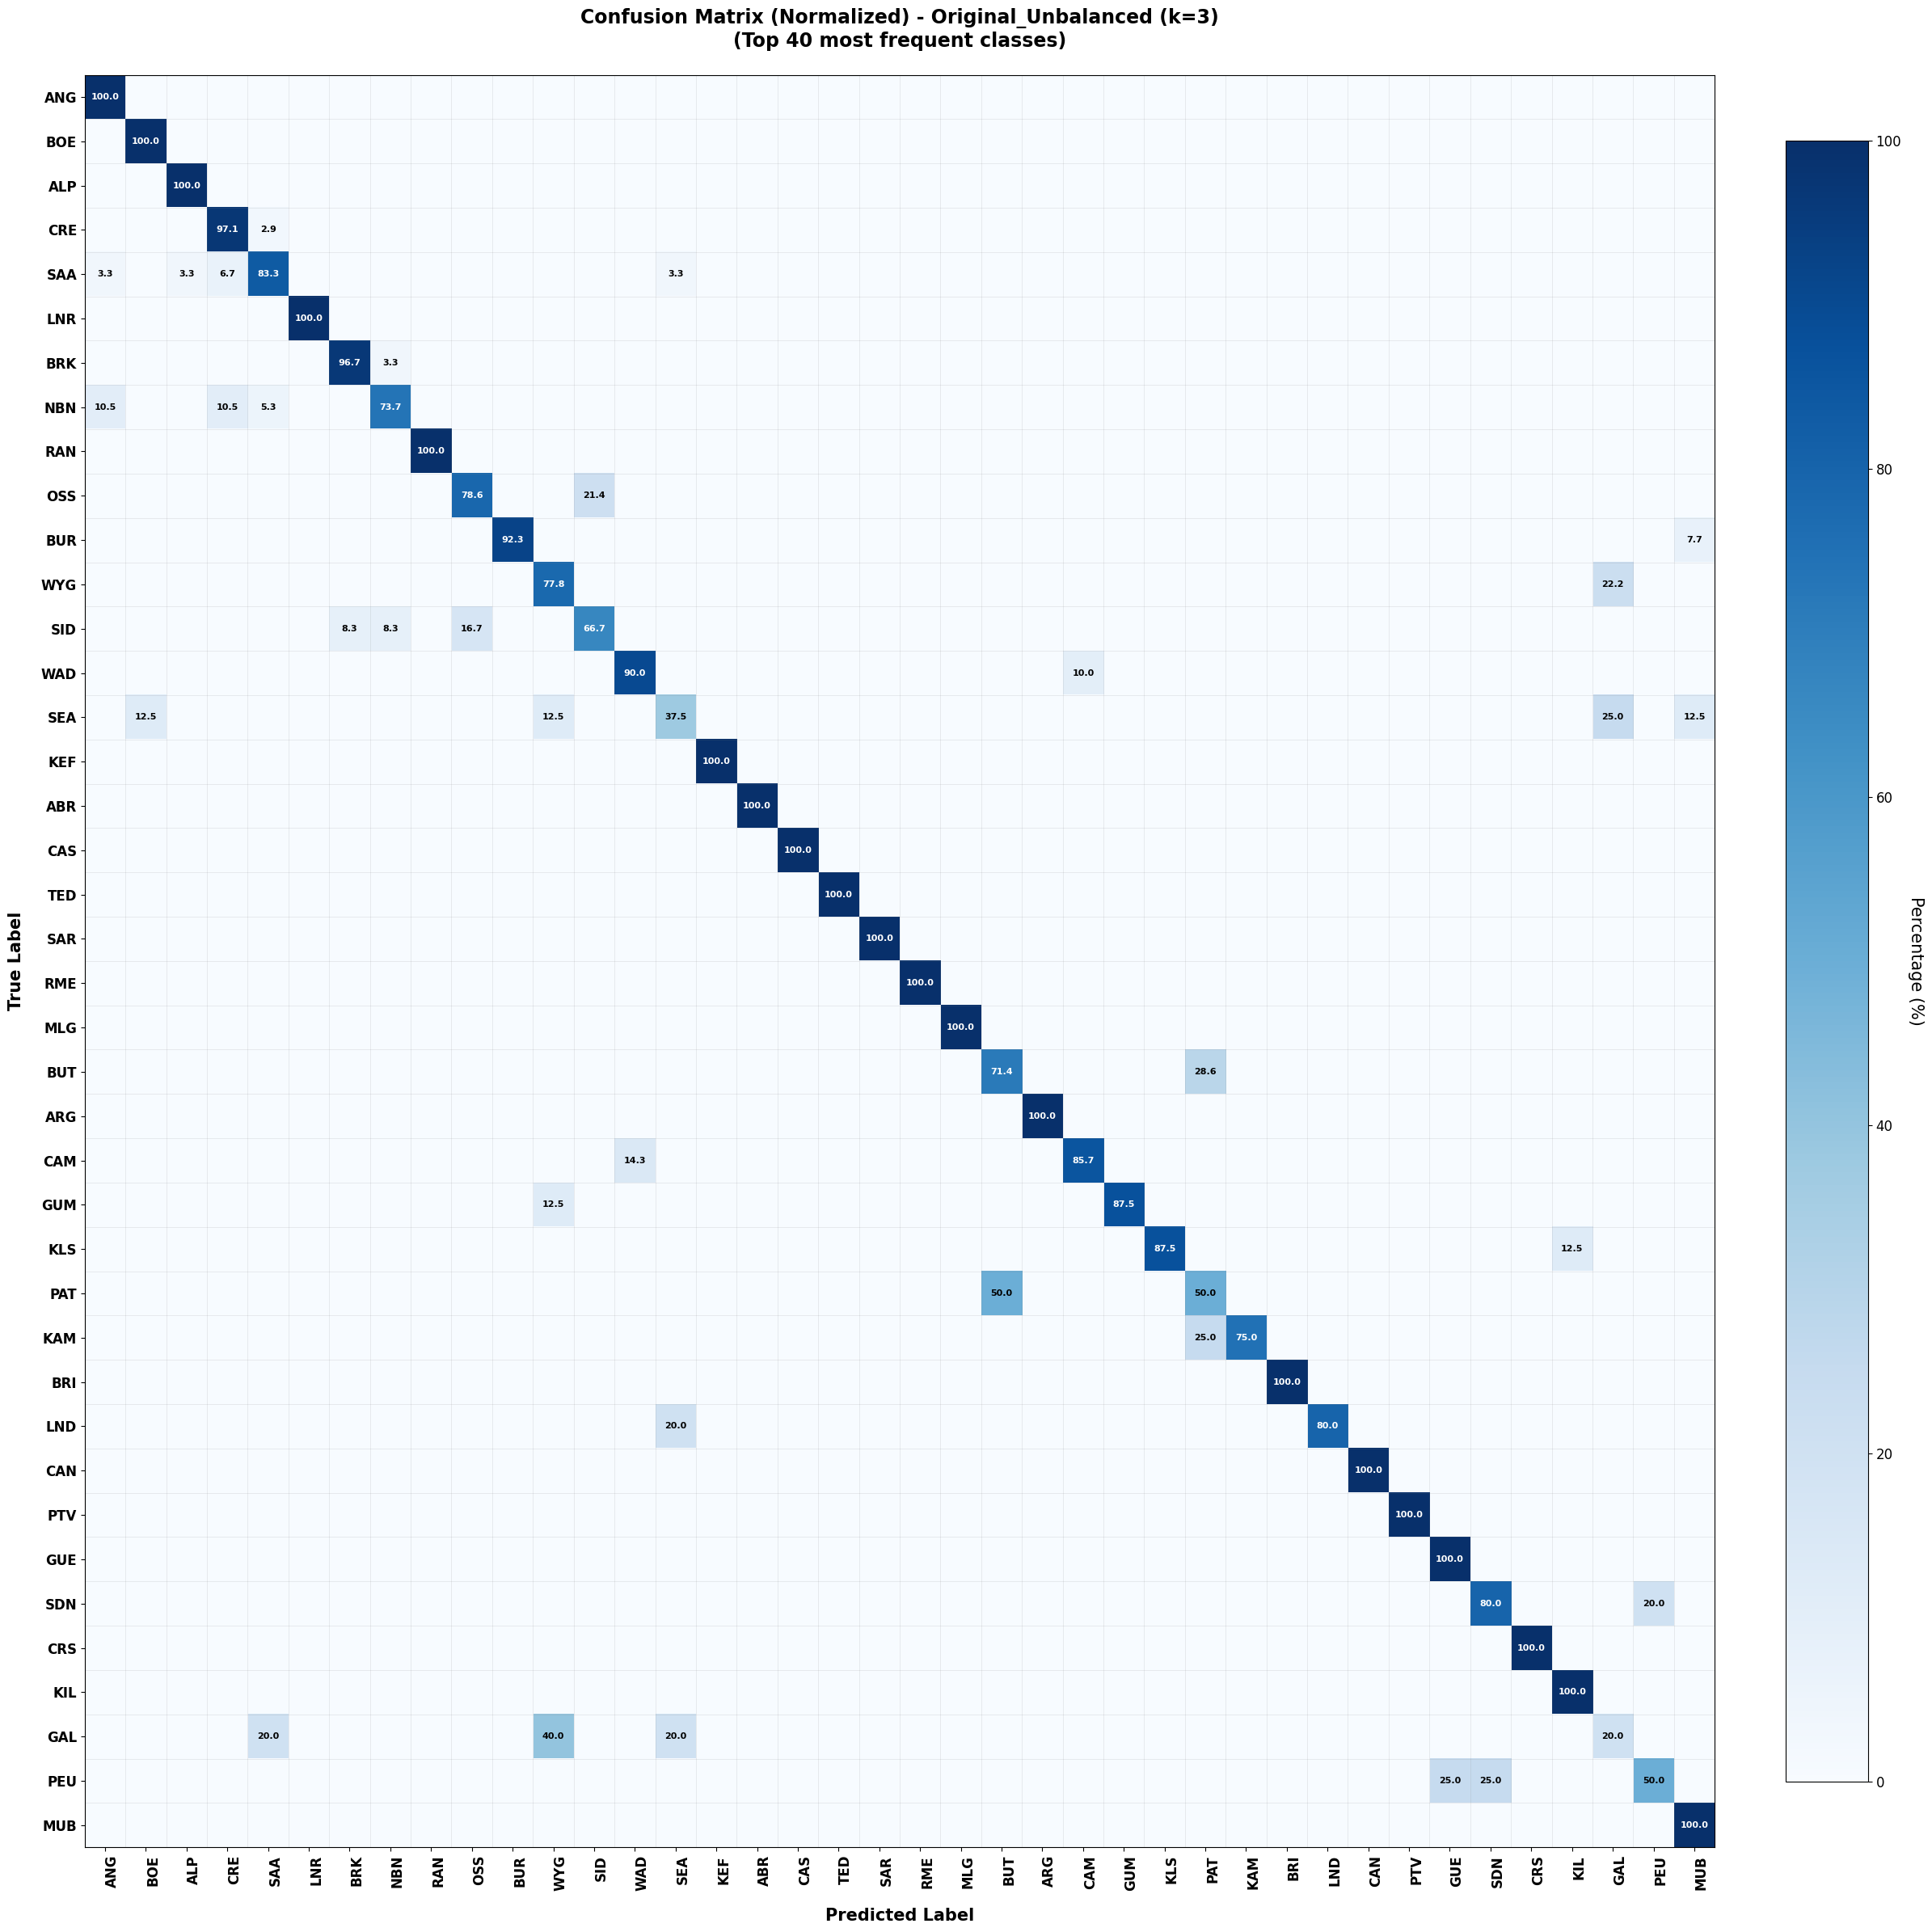

   💾 Confusion matrix saved: confusion_matrix_Original_Unbalanced_k3_normalized.png
   📐 Dimensioni: 24.0x24.0 inch @ 350 DPI
   📊 Risoluzione: ~8400x8400 pixels

   💾 Confusion matrix CSV completo (tutte le 114 classi): confusion_matrix_Original_Unbalanced_k3.csv

      Local Structure (k=5): 0.7956
      Local Structure (k=10): 0.7923

🔄 Loading: Original_Balanced

CARICAMENTO DATASET PLINK: ./data/ADAPTmap_genotypeTOP_20160222_full.bed
📊 Shape iniziale: (4653, 53347) (4653 campioni, 53347 SNP)

🔍 Filtro Razze Rare:
   Razze con ≥10 campioni: 114/144
   Campioni rimossi: 128

🧬 QUALITY CONTROL PIPELINE
────────────────────────────────────────────────────────────
1️⃣  Filtro Missingness SNP...
    ✓ Rimossi 2037 SNP con missingness >10.0%
2️⃣  Imputazione valori mancanti (media)...
    ✓ Imputazione completata
3️⃣  Filtro MAF (Minor Allele Frequency)...
    ✓ Rimossi 4 SNP con MAF <0.01
4️⃣  LD Pruning (Window=50, r²>0.2)...
    Device: cuda
    ...10000/51306 SNP scansionati
    ...1

In [ ]:
# --- VALUTAZIONE CHECKPOINT CON METRICHE PAPER (Local & Global Structure) ---

import os
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score, davies_bouldin_score, confusion_matrix
from sklearn.model_selection import train_test_split
from balance_dataset import balance_dataset_smote

# Percorso checkpoint legacy
LEGACY_CHECKPOINT_DIR = "legacy/checkpoints"

# Coarse Grained Mapping
COARSE_MAPPING = {
    'LATTE': ['ALP', 'ARG', 'ASP', 'BIO', 'CRS', 'GGT', 'KLS', 'LNR', 'MLG', 'MLS', 'MLT', 'MUG', 'NIC', 'ORO', 'PTV', 'RME', 'SAA', 'SAR', 'TOG', 'VSS', 'NRW'],
    'FIBRA': ['ANG', 'ANK', 'CAS'],
    'CARNE': ['BOE', 'RAN', 'TED', 'BRI', 'BEY', 'MOX', 'RAS', 'THA']
}

# Config
BED_PATH = "./data/ADAPTmap_genotypeTOP_20160222_full.bed"
config = {
    'bed_path': BED_PATH,
    'batch_size': 64,
    'maf_thresh': 0.01,
    'geno_thresh': 0.1,
    'min_samples_per_class': 10,
    'ld_pruning': True,
    'ld_threshold': 0.2,
    'ld_window': 50,
    'val_split': 0.15,
    'test_split': 0.15,
    'target_samples': 50,
}

# Configurazioni esperimenti
EXPERIMENTS = [
    {"name": "Original_Unbalanced", "balanced": False, "coarse_mapping": None},
    {"name": "Original_Balanced", "balanced": True, "coarse_mapping": None},
    {"name": "Coarse_Unbalanced", "balanced": False, "coarse_mapping": COARSE_MAPPING},
    {"name": "Coarse_Balanced", "balanced": True, "coarse_mapping": COARSE_MAPPING},
]

# K values to test (Paper uses k=3)
K_VALUES = [3, 5, 10] 

# Numero massimo di classi da visualizzare (modifica questo valore!)
MAX_CLASSES_DISPLAY = 40  # Mostra solo le prime 40 classi più frequenti

results_summary = []

def plot_confusion_matrix(cm, class_names, title, filename, normalize=False, max_classes=None):
    """
    Visualizza e salva la confusion matrix limitata alle classi più frequenti.
    
    Args:
        cm: Confusion matrix completa
        class_names: Nomi di tutte le classi
        title: Titolo del plot
        filename: Nome file per salvare
        normalize: Se True, normalizza per riga (percentuali)
        max_classes: Numero massimo di classi da visualizzare (None = tutte)
    """
    n_classes_total = len(class_names)
    
    # Limita le classi se richiesto
    if max_classes is not None and n_classes_total > max_classes:
        # Calcola le classi più frequenti (somma righe + colonne per importanza)
        class_importance = cm.sum(axis=0) + cm.sum(axis=1)
        top_indices = np.argsort(class_importance)[-max_classes:][::-1]
        
        # Filtra confusion matrix e nomi
        cm = cm[np.ix_(top_indices, top_indices)]
        class_names = class_names[top_indices]
        
        print(f"   📏 Visualizzazione limitata alle top {max_classes} classi (su {n_classes_total} totali)")
        print(f"   💡 CSV completo con tutte le {n_classes_total} classi verrà salvato separatamente")
    else:
        print(f"   📏 Visualizzazione di tutte le {n_classes_total} classi")
    
    n_classes = len(class_names)
    
    if normalize:
        cm_display = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10) * 100
        cmap = 'Blues'
    else:
        cm_display = cm
        cmap = 'Greens'
    
    # Dimensioni scalabili ottimizzate
    fig_size = max(20, n_classes * 0.6)  # Ancora più grande per leggibilità
    
    # Font sizes ottimizzati
    if n_classes <= 10:
        tick_fontsize = 16
        label_fontsize = 18
        title_fontsize = 20
        annotation_fontsize = 12
    elif n_classes <= 30:
        tick_fontsize = 14
        label_fontsize = 16
        title_fontsize = 18
        annotation_fontsize = 10
    elif n_classes <= 50:
        tick_fontsize = 12
        label_fontsize = 15
        title_fontsize = 17
        annotation_fontsize = 8
    else:
        tick_fontsize = 10
        label_fontsize = 13
        title_fontsize = 15
        annotation_fontsize = 7
    
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(cm_display, interpolation='nearest', cmap=cmap, aspect='auto')
    
    # Colorbar
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if normalize:
        cbar.set_label('Percentage (%)', rotation=270, labelpad=20, fontsize=label_fontsize)
    else:
        cbar.set_label('Count', rotation=270, labelpad=20, fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)
    
    # Tick marks
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names, 
           yticklabels=class_names)
    
    # Titolo e label
    if max_classes and n_classes_total > max_classes:
        title = f"{title}\n(Top {n_classes} most frequent classes)"
    ax.set_title(title, fontsize=title_fontsize, pad=25, weight='bold')
    ax.set_ylabel('True Label', fontsize=label_fontsize, weight='bold', labelpad=15)
    ax.set_xlabel('Predicted Label', fontsize=label_fontsize, weight='bold', labelpad=15)
    
    # Rotate labels
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor", 
             fontsize=tick_fontsize, weight='bold')
    plt.setp(ax.get_yticklabels(), fontsize=tick_fontsize, weight='bold')
    
    # Annotazioni
    thresh = cm_display.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm_display[i, j] > thresh else "black"
            if normalize:
                if cm_display[i, j] > 0.5:
                    text = f'{cm_display[i, j]:.1f}'
                    ax.text(j, i, text, ha="center", va="center", 
                           color=color, fontsize=annotation_fontsize, weight='bold')
            else:
                if cm_display[i, j] > 0:
                    text = f'{int(cm_display[i, j])}'
                    ax.text(j, i, text, ha="center", va="center", 
                           color=color, fontsize=annotation_fontsize, weight='bold')
    
    # Griglia leggera
    ax.set_xticks(np.arange(cm.shape[1]) - 0.5, minor=True)
    ax.set_yticks(np.arange(cm.shape[0]) - 0.5, minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5, alpha=0.2)
    ax.tick_params(which="minor", size=0)
    
    fig.tight_layout()
    
    # DPI ottimizzato
    dpi = 350
    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"   💾 Confusion matrix saved: {filename}")
    print(f"   📐 Dimensioni: {fig_size:.1f}x{fig_size:.1f} inch @ {dpi} DPI")
    print(f"   📊 Risoluzione: ~{int(fig_size*dpi)}x{int(fig_size*dpi)} pixels\n")

def calculate_global_structure_score(emb_train, lbl_train, emb_val, lbl_val, coarse_mapping, class_names):
    """
    Calcola la 'Global Structure' (G) come definita nel paper.
    1. Calcola i centroidi per ogni razza nel training set.
    2. Esegue KNN (k=3) sui centroidi.
    3. Verifica se i centroidi vicini appartengono allo stesso super-gruppo (coarse category).
    """
    if coarse_mapping is None:
        return np.nan # Non applicabile se non c'è una gerarchia
        
    # 1. Mappa razze -> categorie
    breed_to_cat = {}
    for cat, breeds in coarse_mapping.items():
        for breed in breeds:
            breed_to_cat[breed] = cat
            
    # 2. Calcola centroidi (Training)
    unique_classes = np.unique(lbl_train)
    centroids = []
    centroid_labels = [] # Indici numerici delle razze
    
    for cls_idx in unique_classes:
        mask = lbl_train == cls_idx
        centroid = np.mean(emb_train[mask], axis=0)
        centroids.append(centroid)
        centroid_labels.append(cls_idx)
        
    centroids = np.array(centroids)
    centroid_labels = np.array(centroid_labels)
    
    # 3. KNN sui centroidi (Leave-One-Out logic simulata su train set stesso o train vs val?)
    # Il paper dice: "KNN on population centroids". Usiamo i centroidi stessi.
    # Per ogni centroide, troviamo i 3 centroidi più vicini (escluso se stesso).
    
    knn = KNeighborsClassifier(n_neighbors=3) # k=3 fisso per Global Structure
    knn.fit(centroids, centroid_labels)
    
    # Troviamo i vicini per ogni centroide
    distances, indices = knn.kneighbors(centroids)
    
    correct_matches = 0
    total_checks = 0
    
    for i, neighbors_idx in enumerate(indices):
        query_breed_name = class_names[centroid_labels[i]]
        
        # Se la razza non è nel mapping (es. rimossa), saltiamo
        if query_breed_name not in breed_to_cat:
            continue
            
        query_cat = breed_to_cat[query_breed_name]
        
        # Controlla i vicini
        for n_idx in neighbors_idx:
            neighbor_breed_name = class_names[centroid_labels[n_idx]]
            if neighbor_breed_name in breed_to_cat:
                neighbor_cat = breed_to_cat[neighbor_breed_name]
                if query_cat == neighbor_cat:
                    correct_matches += 1
                total_checks += 1
                
    if total_checks == 0:
        return 0.0
        
    return correct_matches / total_checks

for exp in EXPERIMENTS:
    print(f"\n{'='*80}")
    print(f"🔄 Loading: {exp['name']}")
    print(f"{'='*80}")
    
    # 1. Setup DataModule
    dm = GenomicDataModule(
        bed_path=config['bed_path'],
        batch_size=config['batch_size'],
        maf_thresh=config['maf_thresh'],
        geno_thresh=config['geno_thresh'],
        min_samples_per_class=config['min_samples_per_class'],
        ld_pruning=config['ld_pruning'],
        ld_threshold=config['ld_threshold'],
        ld_window=config['ld_window'],
        val_split=config['val_split'],
        test_split=config['test_split'],
        coarse_mapping=exp['coarse_mapping']
    )
    dm.setup()
    
    X = dm.X_processed
    y = dm.y_processed
    y_breeds = getattr(dm, 'y_breeds', None)
    
    # Bilanciamento
    if exp['balanced']:
        if exp['coarse_mapping'] and y_breeds is not None:
            X, y_breeds_bal = balance_dataset_smote(X, y_breeds, config['target_samples'])
            breed_to_category = {}
            for cat, breeds in exp['coarse_mapping'].items():
                for breed in breeds:
                    breed_to_category[breed] = cat
            y_bal_labels = np.array([breed_to_category[b] for b in y_breeds_bal])
            y = dm.le.transform(y_bal_labels)
        else:
            X, y = balance_dataset_smote(X, y, config['target_samples'])
    
    # Train/Val split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # 2. Carica Checkpoint
    checkpoint_path = os.path.join(LEGACY_CHECKPOINT_DIR, exp['name'], "best_model.ckpt")
    
    if not os.path.exists(checkpoint_path):
        print(f"⚠️ Checkpoint non trovato: {checkpoint_path}")
        continue
    
    print(f"📂 Loading checkpoint: {checkpoint_path}")
    
    model = ContrastiveGeneticModel.load_from_checkpoint(checkpoint_path)
    model.eval()
    model.freeze()
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # 3. Estrai Embeddings
    train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)), batch_size=128, shuffle=False)
    val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)), batch_size=128, shuffle=False)
    
    emb_train, lbl_train = [], []
    emb_val, lbl_val = [], []
    
    with torch.no_grad():
        for snps, labels in train_loader:
            snps = snps.to(device)
            z = model(snps, augment=False)
            emb_train.append(z.cpu().numpy())
            lbl_train.append(labels.numpy())
        
        for snps, labels in val_loader:
            snps = snps.to(device)
            z = model(snps, augment=False)
            emb_val.append(z.cpu().numpy())
            lbl_val.append(labels.numpy())
    
    emb_train = np.concatenate(emb_train)
    lbl_train = np.concatenate(lbl_train)
    emb_val = np.concatenate(emb_val)
    lbl_val = np.concatenate(lbl_val)
    
    # 4. Calcola Metriche
    print(f"   📊 Calculating metrics...")
    
    # Silhouette & Davies-Bouldin
    sil = silhouette_score(emb_val, lbl_val) if len(np.unique(lbl_val)) > 1 else 0
    db = davies_bouldin_score(emb_val, lbl_val) if len(np.unique(lbl_val)) > 1 else 0
    
    # Global Structure (solo se siamo in modalità "Original" o abbiamo accesso al mapping)
    # Nota: Se l'esperimento è "Coarse", le label sono già le categorie, quindi Global Structure perde senso (o è banale).
    # Ha senso calcolarla per "Original" usando il mapping esterno.
    global_score = np.nan
    if "Original" in exp['name']:
        global_score = calculate_global_structure_score(
            emb_train, lbl_train, emb_val, lbl_val, 
            COARSE_MAPPING, dm.class_names
        )
    
    row = {
        "Experiment": exp['name'],
        "Silhouette": sil,
        "Davies-Bouldin": db,
        "Global Structure (k=3)": global_score
    }
    
    print(f"      Silhouette: {sil:.4f}")
    print(f"      Davies-Bouldin: {db:.4f}")
    if not np.isnan(global_score):
        print(f"      Global Structure: {global_score:.4f}")
    
    # KNN Accuracy + Confusion Matrix
    for k in K_VALUES:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(emb_train, lbl_train)
        acc = knn.score(emb_val, lbl_val)
        row[f"Local Structure (KNN k={k})"] = acc
        print(f"      Local Structure (k={k}): {acc:.4f}")
        
        # Confusion Matrix (solo per k=3)
        if k == 3:
            y_pred = knn.predict(emb_val)
            cm = confusion_matrix(lbl_val, y_pred)
            
            print(f"\n   📊 Generating Confusion Matrices (k={k})...")
            
            # Salva confusion matrix numerica (LIMITATA per visualizzazione)
            plot_confusion_matrix(
                cm, 
                dm.class_names, 
                f'Confusion Matrix - {exp["name"]} (k={k})',
                f'confusion_matrix_{exp["name"]}_k{k}.png',
                normalize=False,
                max_classes=MAX_CLASSES_DISPLAY
            )
            
            # Salva confusion matrix normalizzata (LIMITATA per visualizzazione)
            plot_confusion_matrix(
                cm, 
                dm.class_names, 
                f'Confusion Matrix (Normalized) - {exp["name"]} (k={k})',
                f'confusion_matrix_{exp["name"]}_k{k}_normalized.png',
                normalize=True,
                max_classes=MAX_CLASSES_DISPLAY
            )
            
            # Salva CSV COMPLETO con TUTTE le classi (non limitato)
            cm_df = pd.DataFrame(cm, index=dm.class_names, columns=dm.class_names)
            cm_df.to_csv(f'confusion_matrix_{exp["name"]}_k{k}.csv')
            print(f"   💾 Confusion matrix CSV completo (tutte le {len(dm.class_names)} classi): confusion_matrix_{exp['name']}_k{k}.csv\n")
        
    results_summary.append(row)

# 5. Save Results
print(f"\n\n{'='*80}")
print("🏆 FINAL LEGACY EVALUATION RESULTS")
print(f"{'='*80}")

df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))

df_results.to_csv("legacy_evaluation_metrics.csv", index=False)
print("\n✅ Results saved to legacy_evaluation_metrics.csv")
